<h1 style="color:magenta;">NSL - Exercises 05 </h1>

### 2/4/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 1
The aim of this exercise is to use the Metropolis algorithm to sample the probability density $|\Psi(\vec{r})|^2$ of the Hydrogen atom in Cartesian coordinates for 

$$
\Psi_{1,0,0}(r,\theta,\phi)=
\frac{a_0^{-3/2}}{\sqrt{\pi}} e^{-r/a_0} 
$$

$$
\Psi_{2,1,0}(r,\theta,\phi)=
\frac{a_0^{-5/2}}{8}\sqrt{\frac{2}{\pi}} r e^{-r/2a_0} \cos(\theta)
$$
Expectation values for the radius turn out to be exactly:
$$
\left\langle r \right\rangle_{\Psi_{1,0,0}} = \frac{3}{2}a_0
\quad
\left\langle r \right\rangle_{\Psi_{2,1,0}} = 5 a_0
$$

First of all I created two functions for the Metropolis algorithm in my main.cpp, one for each probability density:

$$
|\Psi_{1,0,0}(x,y,z)|^2 = \frac{1}{\pi a_0^3} e^{-\frac{2\sqrt{x^2+y^2+z^2}}{a_0}} \quad \quad |\Psi_{2,1,0}(x,y,z)|^2 = \frac{1}{64\pi a_0^5} z^2 e^{-\frac{\sqrt{x^2+y^2+z^2}}{a_0}}
$$

### Uniform sampling

By sampling uniformly these distributions, I estimated the expectation value of the radius $\langle r \rangle$ and compared it with the analytical results.

It was requested to obtain a transition rate $T(\vec{x}|\vec{y}) \approx 50%$, therefore I adjusted the sampling intervals of each PDF ($[-1.2 \cdot a, +1.2 \cdot a] $ for $\Psi_{1, 0, 0}$ and $[-4.8 \cdot a, +4.8 \cdot a]$ for $\Psi_{2, 1, 0}$).

Before starting the measurement (data blocking), an equilibration phase was performed. When starting the simulation, the algorithm spends the first $5000$ steps drifting towards the high-probability region (the origin). Measurements taken during this drift would bias the final average, thus they were discarded.

The following plots show the estimation of $\langle r \rangle$ as a function of the number of blocks $N=100$, using $M = 10^6$ total throws.


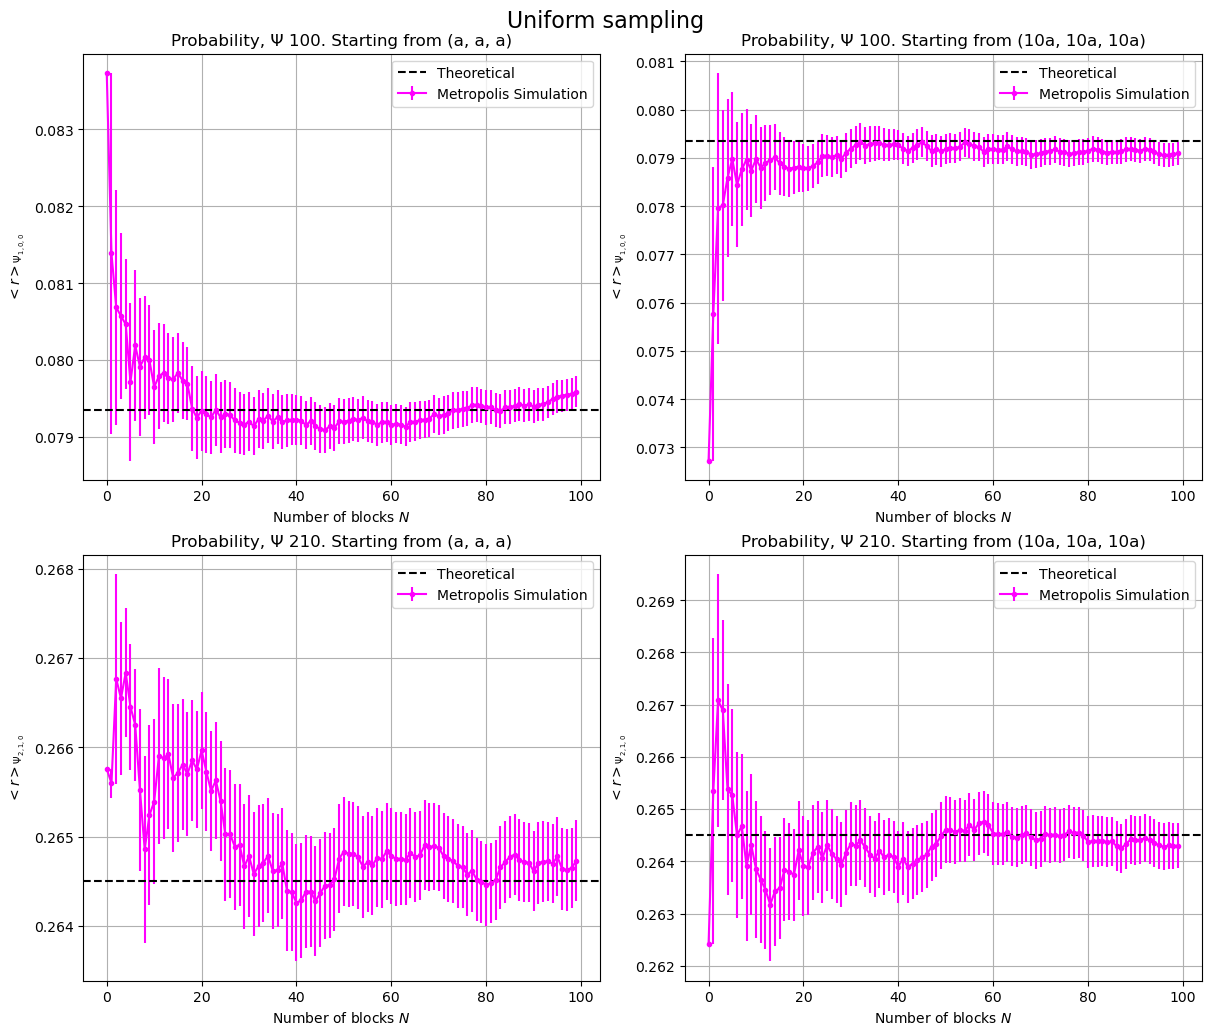

In [14]:
import matplotlib.pyplot as plt
import numpy as np

data_100 = np.loadtxt("./Ex/output_100.dat")
data_100_far = np.loadtxt("./Ex/output_100_far.dat")
data_210 = np.loadtxt("./Ex/output_210.dat")
data_210_far = np.loadtxt("./Ex/output_210_far.dat")

x_100 = data_100[:, 0]
y_100 = data_100[:, 1]
err_100 = data_100[:, 2]

x_100_far = data_100_far[:, 0]
y_100_far = data_100_far[:, 1]
err_100_far = data_100_far[:, 2]

x_210 = data_210[:, 0]
y_210 = data_210[:, 1]
err_210 = data_210[:, 2]

x_210_far = data_210_far[:, 0]
y_210_far = data_210_far[:, 1]
err_210_far = data_210_far[:, 2]

fig, ax = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

ax[0, 0].errorbar(x_100, y_100, yerr=err_100, fmt='.-', color='magenta', label='Metropolis Simulation')
ax[0, 0].set_title("Probability, Ψ 100. Starting from (a, a, a)")
ax[0, 0].set_xlabel("Number of blocks $N$")
ax[0, 0].set_ylabel("$<r>_{\Psi_{1,0,0}}$")
ax[0, 0].axhline(y=1.5*0.0529, color='black', linestyle='--', label='Theoretical')
ax[0, 0].legend()
ax[0, 0].grid(True)

ax[0, 1].errorbar(x_100_far, y_100_far, yerr=err_100_far, fmt='.-', color='magenta', label='Metropolis Simulation')
ax[0, 1].set_title("Probability, Ψ 100. Starting from (10a, 10a, 10a)")
ax[0, 1].set_xlabel("Number of blocks $N$")
ax[0, 1].set_ylabel("$<r>_{\Psi_{1,0,0}}$")
ax[0, 1].axhline(y=1.5*0.0529, color='black', linestyle='--', label='Theoretical')
ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].errorbar(x_210, y_210, yerr=err_210, fmt='.-', color='magenta', label='Metropolis Simulation')
ax[1, 0].set_title("Probability, Ψ 210. Starting from (a, a, a)")
ax[1, 0].set_xlabel("Number of blocks $N$")
ax[1, 0].set_ylabel("$<r>_{\Psi_{2,1,0}}$")
ax[1, 0].axhline(y=5*0.0529, color='black', linestyle='--', label='Theoretical')
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[1, 1].errorbar(x_210_far, y_210_far, yerr=err_210_far, fmt='.-', color='magenta', label='Metropolis Simulation')
ax[1, 1].set_title("Probability, Ψ 210. Starting from (10a, 10a, 10a)")
ax[1, 1].set_xlabel("Number of blocks $N$")
ax[1, 1].set_ylabel("$ <r>_{\Psi_{2,1,0}}$")
ax[1, 1].axhline(y=5*0.0529, color='black', linestyle='--', label='Theoretical')
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.suptitle('Uniform sampling', fontsize=16, y=1.02)

plt.show()


All simulations converge to the same analytical values ($\frac{3}{2}$ and $5$).

The error bars, calculated via the data blocking method, decrease as $1/\sqrt{N_{blocks}}$, showing that the estimates are statistically consistent.

If I took away the equilibration in the code, it would be clear that starting far away from the origin takes more time to reach the origin.

Here we can see how the sampled point distribute in the 3D space.

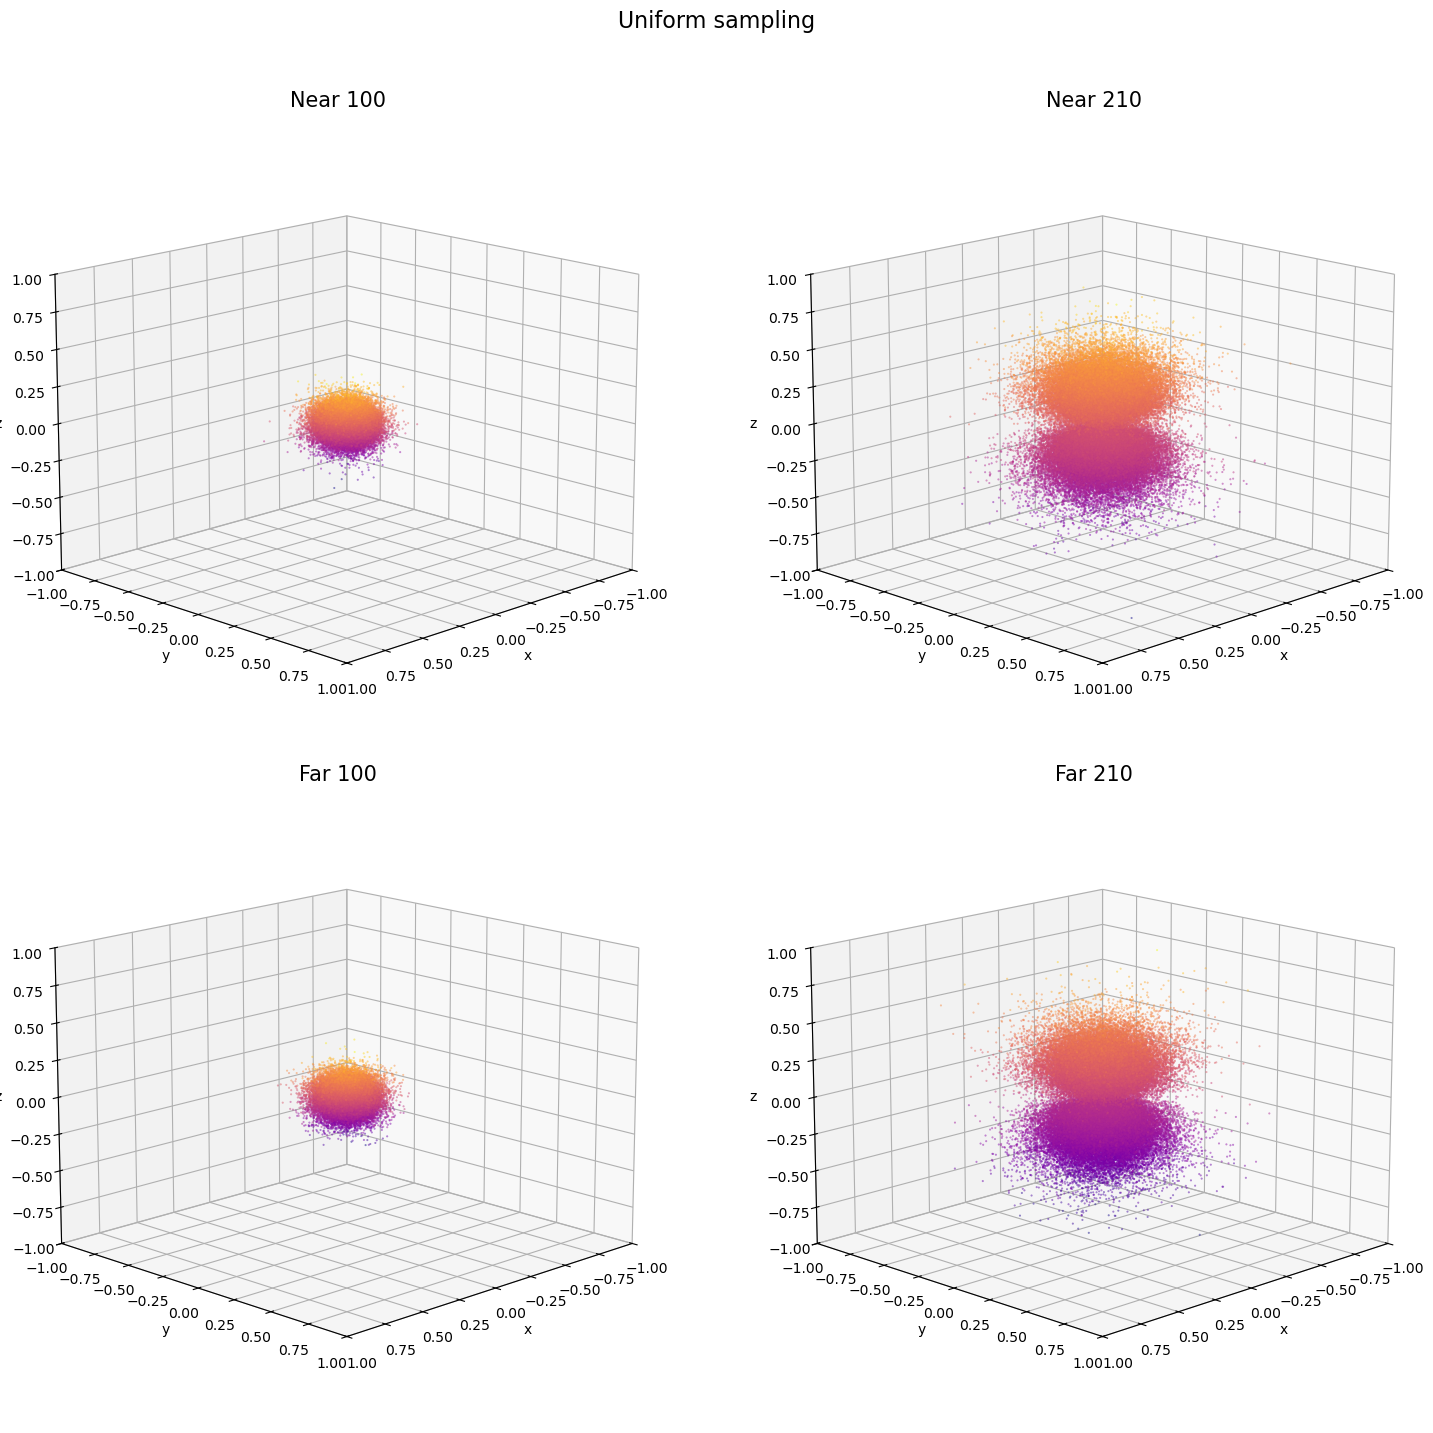

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

data_near_100 = np.loadtxt("./Ex/pos_near_unif_100.dat", skiprows=1)
data_near_210 = np.loadtxt("./Ex/pos_near_unif_210.dat", skiprows=1)
data_far_100 = np.loadtxt("./Ex/pos_far_unif_100.dat", skiprows=1)
data_far_210 = np.loadtxt("./Ex/pos_far_unif_210.dat", skiprows=1)

datasets = [data_near_100, data_near_210, data_far_100, data_far_210]
titles = ["Near 100", "Near 210", "Far 100", "Far 210"]

fig = plt.figure(figsize=(16, 14))
step = 10

for i in range(4):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    d = datasets[i]
    x, y, z = d[::step, 0], d[::step, 1], d[::step, 2]
    
    p = ax.scatter(x, y, z, c=z, marker='.', s=1, cmap='plasma', alpha=0.5)
    
    ax.set_title(titles[i], fontsize=15)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    ax.set_xlim(-1, 1) 
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    
    ax.view_init(15, 45)

plt.suptitle('Uniform sampling', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

### Gaussian sampling

By sampling gaussianly these distributions, I estimated the expectation value of the radius $\langle r \rangle$ and compared it with the analytical results.

It was requested to obtain a transition rate $T(\vec{x}|\vec{y}) \approx 50%$, therefore I adjusted the sigma for each PDF: $\sigma_{100}=0.75 \cdot a$ and $\sigma_{210}=1.87 \cdot a$.

Before starting the measurement (data blocking), an equilibration phase was performed. When starting the simulation, the algorithm spends the first $2000$ steps drifting towards the high-probability region (the origin). Measurements taken during this drift would bias the final average, thus they were discarded.

The following plots show the estimation of $\langle r \rangle$ as a function of the number of blocks $N=100$, using $M = 10^6$ total throws. 

The statistical considerations made for the uniform transition probability still hold. In terms of sampling efficiency, the Gaussian transition allows the system to explore the phase space more dynamically. While maintaining the same $50\%$ acceptance rate, the tails of the Gaussian distribution occasionally propose larger spatial displacements, which helps reduce the autocorrelation time between consecutive random walks. As expected by the ergodicity of the Metropolis algorithm, both transition methods asymptotically converge to the same analytical expectation values: $\langle r \rangle_{\Psi_{1,0,0}} = \frac{3}{2}a_0$ and $\langle r \rangle_{\Psi_{2,1,0}} = 5a_0$.


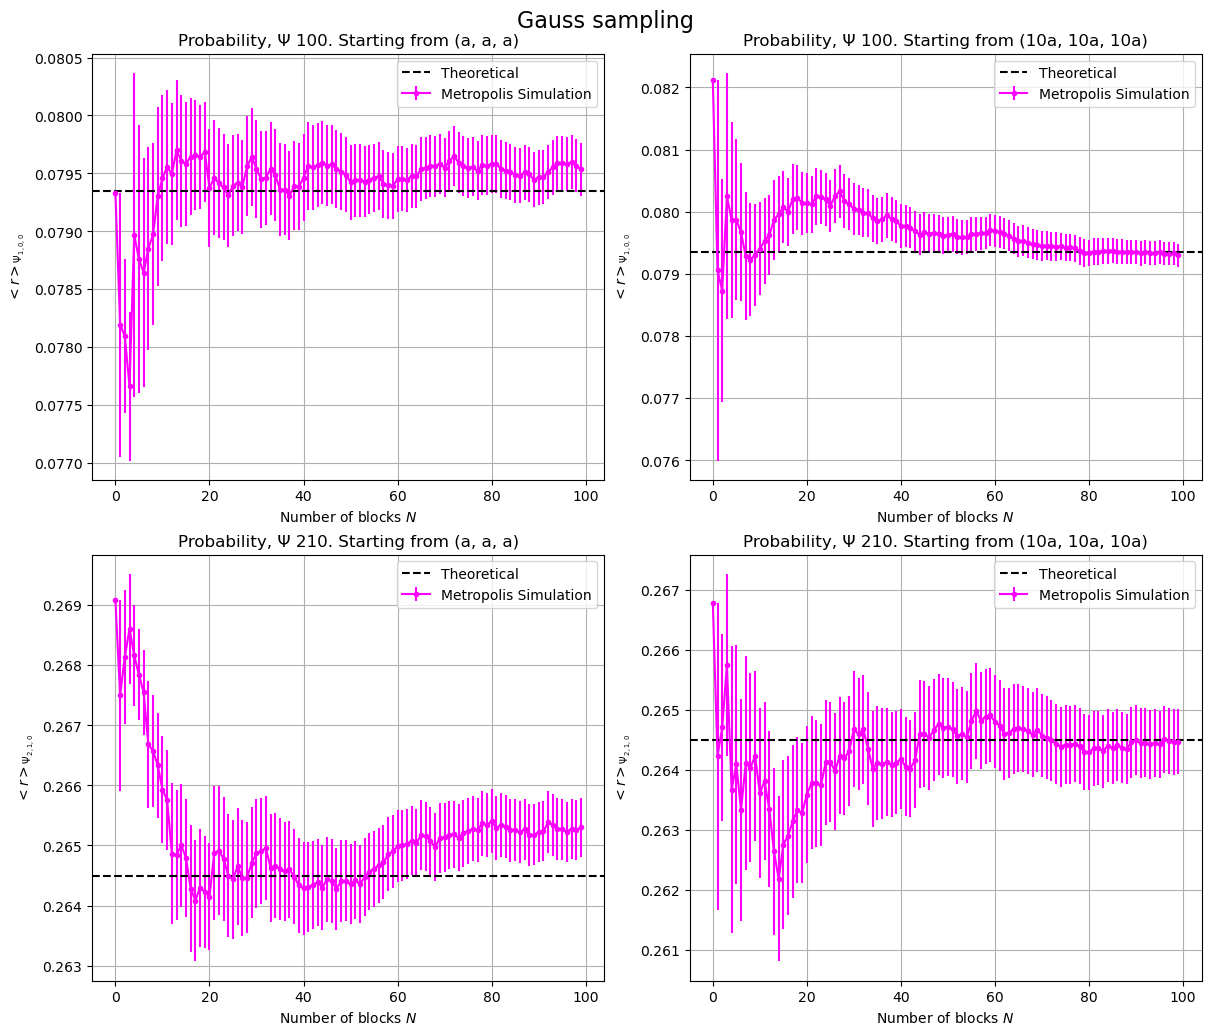

In [16]:
import matplotlib.pyplot as plt
import numpy as np

data_100 = np.loadtxt("./Ex/output_100_gauss.dat")
data_100_far = np.loadtxt("./Ex/output_100_far_gauss.dat")
data_210 = np.loadtxt("./Ex/output_210_gauss.dat")
data_210_far = np.loadtxt("./Ex/output_210_far_gauss.dat")

x_100 = data_100[:, 0]
y_100 = data_100[:, 1]
err_100 = data_100[:, 2]

x_100_far = data_100_far[:, 0]
y_100_far = data_100_far[:, 1]
err_100_far = data_100_far[:, 2]

x_210 = data_210[:, 0]
y_210 = data_210[:, 1]
err_210 = data_210[:, 2]

x_210_far = data_210_far[:, 0]
y_210_far = data_210_far[:, 1]
err_210_far = data_210_far[:, 2]

fig, ax = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

ax[0, 0].errorbar(x_100, y_100, yerr=err_100, fmt='.-', color='magenta', label='Metropolis Simulation')
ax[0, 0].set_title("Probability, Ψ 100. Starting from (a, a, a)")
ax[0, 0].set_xlabel("Number of blocks $N$")
ax[0, 0].set_ylabel("$<r>_{\Psi_{1,0,0}}$")
ax[0, 0].axhline(y=1.5*0.0529, color='black', linestyle='--', label='Theoretical')
ax[0, 0].legend()
ax[0, 0].grid(True)

ax[0, 1].errorbar(x_100_far, y_100_far, yerr=err_100_far, fmt='.-', color='magenta', label='Metropolis Simulation')
ax[0, 1].set_title("Probability, Ψ 100. Starting from (10a, 10a, 10a)")
ax[0, 1].set_xlabel("Number of blocks $N$")
ax[0, 1].set_ylabel("$<r>_{\Psi_{1,0,0}}$")
ax[0, 1].axhline(y=1.5*0.0529, color='black', linestyle='--', label='Theoretical')
ax[0, 1].legend()
ax[0, 1].grid(True)

ax[1, 0].errorbar(x_210, y_210, yerr=err_210, fmt='.-', color='magenta', label='Metropolis Simulation')
ax[1, 0].set_title("Probability, Ψ 210. Starting from (a, a, a)")
ax[1, 0].set_xlabel("Number of blocks $N$")
ax[1, 0].set_ylabel("$<r>_{\Psi_{2,1,0}}$")
ax[1, 0].axhline(y=5*0.0529, color='black', linestyle='--', label='Theoretical')
ax[1, 0].legend()
ax[1, 0].grid(True)

ax[1, 1].errorbar(x_210_far, y_210_far, yerr=err_210_far, fmt='.-', color='magenta', label='Metropolis Simulation')
ax[1, 1].set_title("Probability, Ψ 210. Starting from (10a, 10a, 10a)")
ax[1, 1].set_xlabel("Number of blocks $N$")
ax[1, 1].set_ylabel("$ <r>_{\Psi_{2,1,0}}$")
ax[1, 1].axhline(y=5*0.0529, color='black', linestyle='--', label='Theoretical')
ax[1, 1].legend()
ax[1, 1].grid(True)

plt.suptitle('Gauss sampling', fontsize=16, y=1.02)

plt.show()


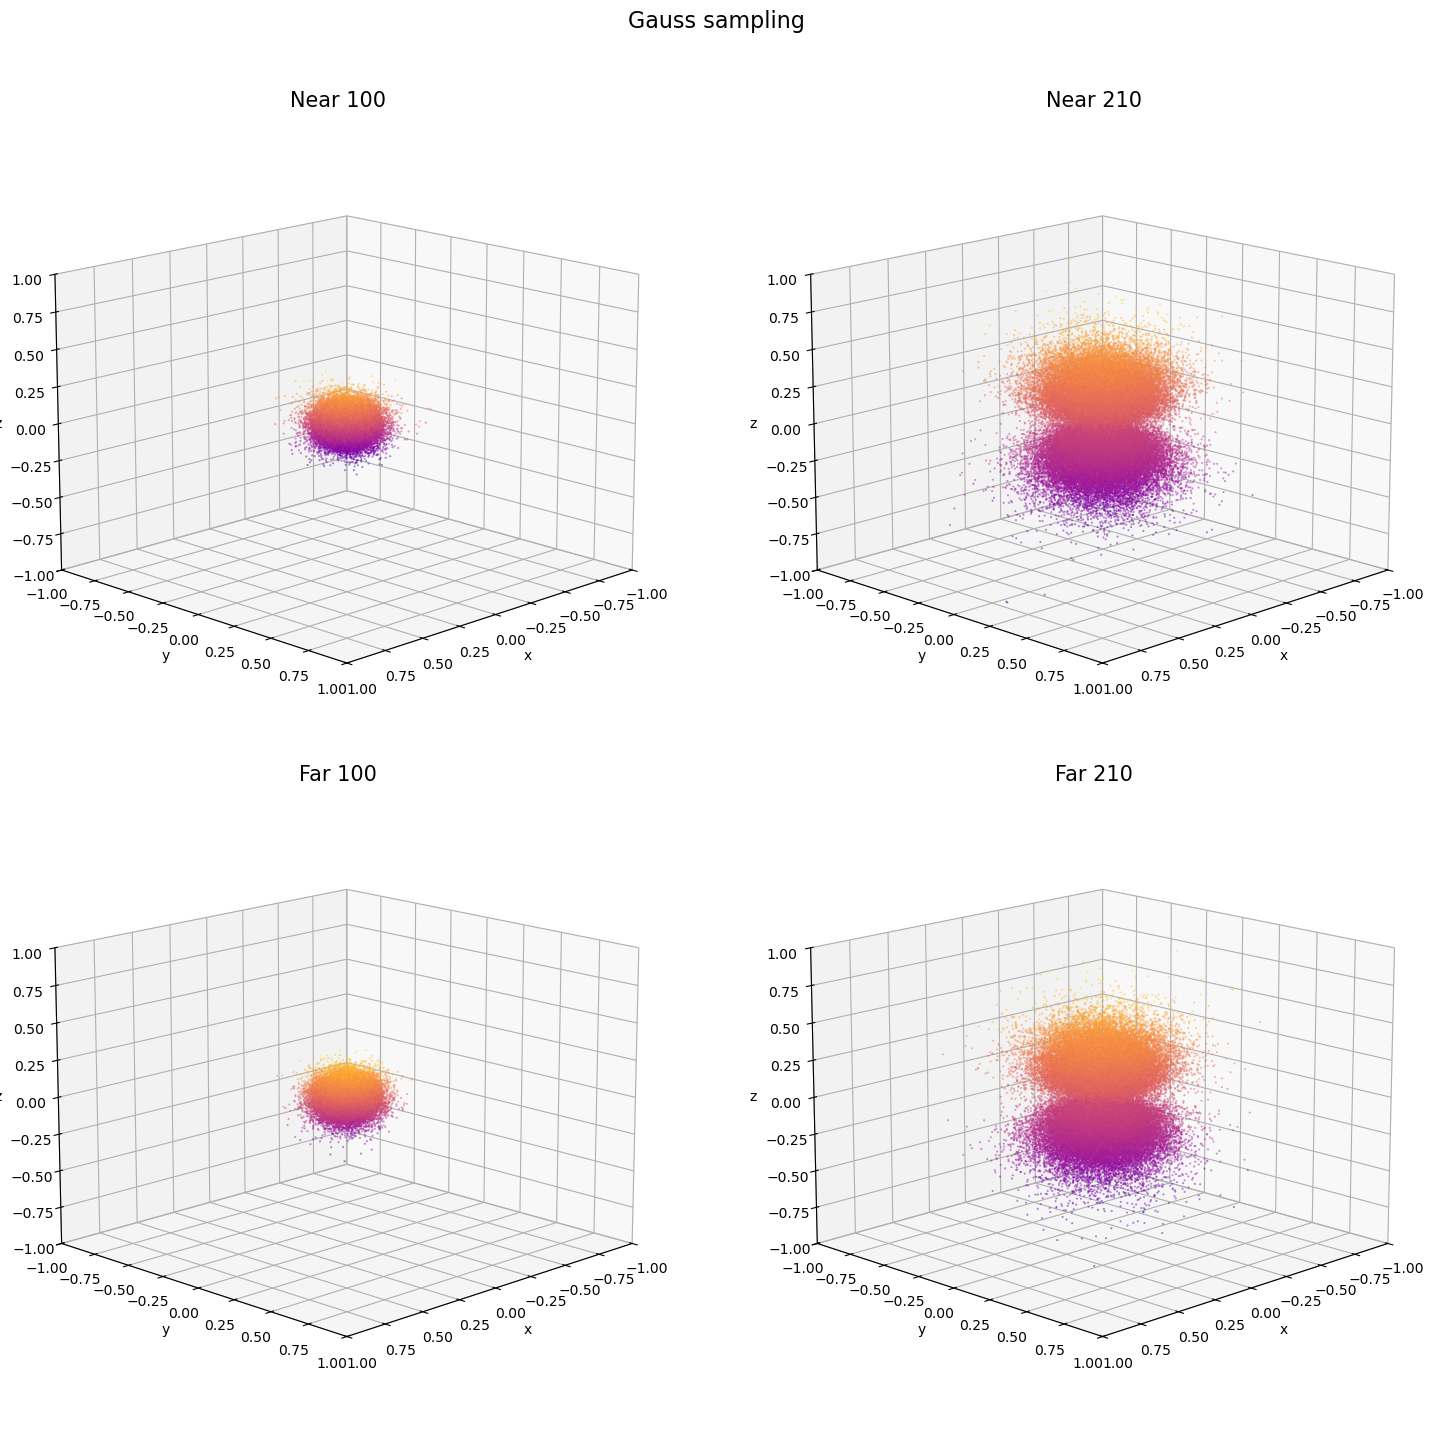

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

data_near_100 = np.loadtxt("./Ex/pos_near_gauss_100.dat", skiprows=1)
data_near_210 = np.loadtxt("./Ex/pos_near_gauss_210.dat", skiprows=1)
data_far_100 = np.loadtxt("./Ex/pos_far_gauss_100.dat", skiprows=1)
data_far_210 = np.loadtxt("./Ex/pos_far_gauss_210.dat", skiprows=1)

datasets = [data_near_100, data_near_210, data_far_100, data_far_210]
titles = ["Near 100", "Near 210", "Far 100", "Far 210"]

fig = plt.figure(figsize=(16, 14))
step = 10

for i in range(4):
    ax = fig.add_subplot(2, 2, i+1, projection='3d')
    
    d = datasets[i]
    x, y, z = d[::step, 0], d[::step, 1], d[::step, 2]
    
    p = ax.scatter(x, y, z, c=z, marker='.', s=1, cmap='plasma', alpha=0.5)
    
    ax.set_title(titles[i], fontsize=15)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    
    ax.set_xlim(-1, 1) 
    ax.set_ylim(-1, 1)
    ax.set_zlim(-1, 1)
    
    ax.view_init(15, 45)

plt.suptitle('Gauss sampling', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

In conclusion, the number of Monte Carlo Metropolis steps in each block should be large at least 3 times the autocorrelation time between each block.